In [9]:
!pip install pandas numpy matplotlib seaborn plotly jupyter --upgrade --quiet

In [10]:
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots

print(f" NumPy version: {np.__version__}")
print(f" Pandas version: {pd.__version__}")
print(f" Plotly version: {plotly.__version__}")  # Use plotly, not px
print(f" Matplotlib version: {plt.matplotlib.__version__}")
print("\n All packages ready!")

 NumPy version: 2.5.3
 Pandas version: 3.0.5
 Plotly version: 7.0.0
 Matplotlib version: 3.11.2

 All packages ready!


In [11]:
   import os
   print(os.getcwd())  

C:\Users\rohan


In [12]:
import pandas as pd

df = pd.read_excel('C:\\Users\\rohan\\vehicles_dataset.xlsx')
df.head()

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [13]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Shape: {df.shape[0]} rowsx {df.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(df.dtypes)

print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW

Dataset Shape: 1002 rowsx 18 columns

Column Names and Types:
name                  str
description           str
make                  str
model              object
type                  str
year                int64
price             float64
engine                str
cylinders         float64
fuel                  str
mileage           float64
transmission          str
trim                  str
body                  str
doors             float64
exterior_color        str
interior_color        str
drivetrain            str
dtype: object

First 5 rows:


,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [14]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
})

print(missing_df[missing_df['Missing_Count'] > 0].to_string())

            Column  Missing_Count  Missing_Percentage
1      description             56            5.588822
6            price             23            2.295409
7           engine              2            0.199601
8        cylinders            105           10.479042
9             fuel              7            0.698603
10         mileage             34            3.393214
11    transmission              2            0.199601
12            trim              1            0.099800
13            body              3            0.299401
14           doors              7            0.698603
15  exterior_color              5            0.499002
16  interior_color             38            3.792415


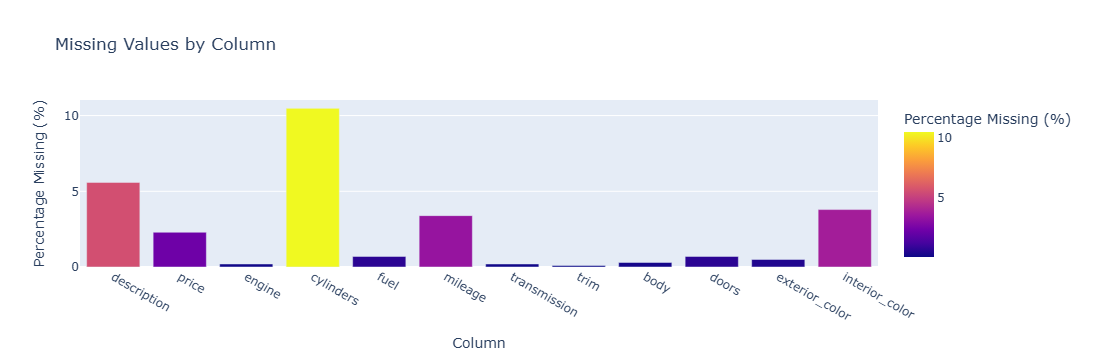

In [15]:
fig = px.bar(
    missing_df[missing_df['Missing_Count'] > 0],
    x='Column',
    y='Missing_Percentage',
    title='Missing Values by Column',
    labels={'Missing_Percentage': 'Percentage Missing (%)'},
    color='Missing_Percentage'
)
fig.show()

In [16]:
print("\nHandling Missing Values...")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val)
        print(f" Filled {col} with median: {median_val}")


categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val)
        print(f" Filled {col} with mode: {mode_val}")

print(f"\n All missing values handled")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


Handling Missing Values...
 Filled price with median: 47165.0
 Filled cylinders with median: 4.0
 Filled mileage with median: 8.0
 Filled doors with median: 4.0
 Filled description with mode: 
      
        .
      
    
 Filled engine with mode: 16V GDI DOHC Turbo
 Filled fuel with mode: Gasoline
 Filled transmission with mode: 8-Speed Automatic
 Filled trim with mode: Limited
 Filled body with mode: SUV
 Filled exterior_color with mode: Bright White Clearcoat
 Filled interior_color with mode: Black

 All missing values handled
Remaining missing values: 283


C:\Users\rohan\AppData\Local\Temp\ipykernel_14864\2507996704.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [17]:
print("\n" + "="*60)
print("DUPLICATE VALUES ANALYSIS")
print("="*60)

duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicate_count} duplicate rows")
    print(f"New shape: {df.shape}")

for col in ['price', 'mileage']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col.upper()}:")
    print(f"  Q1: ${Q1:,.0f} | Q3: ${Q3:,.0f} | IQR: ${IQR:,.0f}")
    print(f"  Lower bound: ${lower_bound:,.0f}")
    print(f"  Upper bound: ${upper_bound:,.0f}")
    print(f"  Outlier count: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    


DUPLICATE VALUES ANALYSIS
Total duplicate rows: 24
Removed 24 duplicate rows
New shape: (978, 18)

PRICE:
  Q1: $36,772 | Q3: $59,076 | IQR: $22,304
  Lower bound: $3,315
  Upper bound: $92,533
  Outlier count: 25 (2.6%)

MILEAGE:
  Q1: $4 | Q3: $13 | IQR: $9
  Lower bound: $-10
  Upper bound: $26
  Outlier count: 99 (10.1%)


In [18]:
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print("\nNUMERIC COLUMNS:")
summary = df.describe().T
summary['range'] = summary['max'] - summary['min']
print(summary[['count', 'mean', 'std', 'min', 'max', 'range']])




STATISTICAL SUMMARY

NUMERIC COLUMNS:
           count          mean           std     min       max     range
year       978.0   2023.922290      0.289874  2023.0    2025.0       2.0
price      955.0  50314.982199  18795.326296     0.0  195895.0  195895.0
cylinders  875.0      4.962286      1.379714     0.0       8.0       8.0
mileage    946.0     70.359408    513.229062     0.0    9711.0    9711.0
doors      971.0      3.942327      0.277638     2.0       5.0       3.0


In [19]:
print("\n" + "-" * 70)
print("📋 CATEGORICAL COLUMNS:")
print("-" * 70)

skip_columns = ['description', 'name', 'engine', 'trim']

for col in df.select_dtypes(include=['object', 'str']).columns:
    
    if col in skip_columns:
        continue
    
    print(f"\n{col.upper()}:")
    
    unique_count = df[col].nunique()
    print(f"  Unique values: {unique_count}")
    
    top_values = df[col].value_counts().head(5)
    
    if len(top_values) > 0:
        print(f"  Top 5:")
        for value, count in top_values.items():
            percentage = (count / len(df)) * 100
            print(f"    • {str(value):30s}: {count:4d} ({percentage:5.1f}%)")

print("\n" + "="*70)


----------------------------------------------------------------------
📋 CATEGORICAL COLUMNS:
----------------------------------------------------------------------

MAKE:
  Unique values: 28
  Top 5:
    • Jeep                          :  192 ( 19.6%)
    • Hyundai                       :  121 ( 12.4%)
    • Dodge                         :  107 ( 10.9%)
    • Ford                          :   88 (  9.0%)
    • RAM                           :   79 (  8.1%)

MODEL:
  Unique values: 153
  Top 5:
    • Hornet                        :   63 (  6.4%)
    • 3500                          :   52 (  5.3%)
    • Compass                       :   46 (  4.7%)
    • Durango                       :   38 (  3.9%)
    • Tucson Hybrid                 :   33 (  3.4%)

TYPE:
  Unique values: 1
  Top 5:
    • New                           :  978 (100.0%)

FUEL:
  Unique values: 7
  Top 5:
    • Gasoline                      :  644 ( 65.8%)
    • Hybrid                        :  136 ( 13.9%)
    • Electric

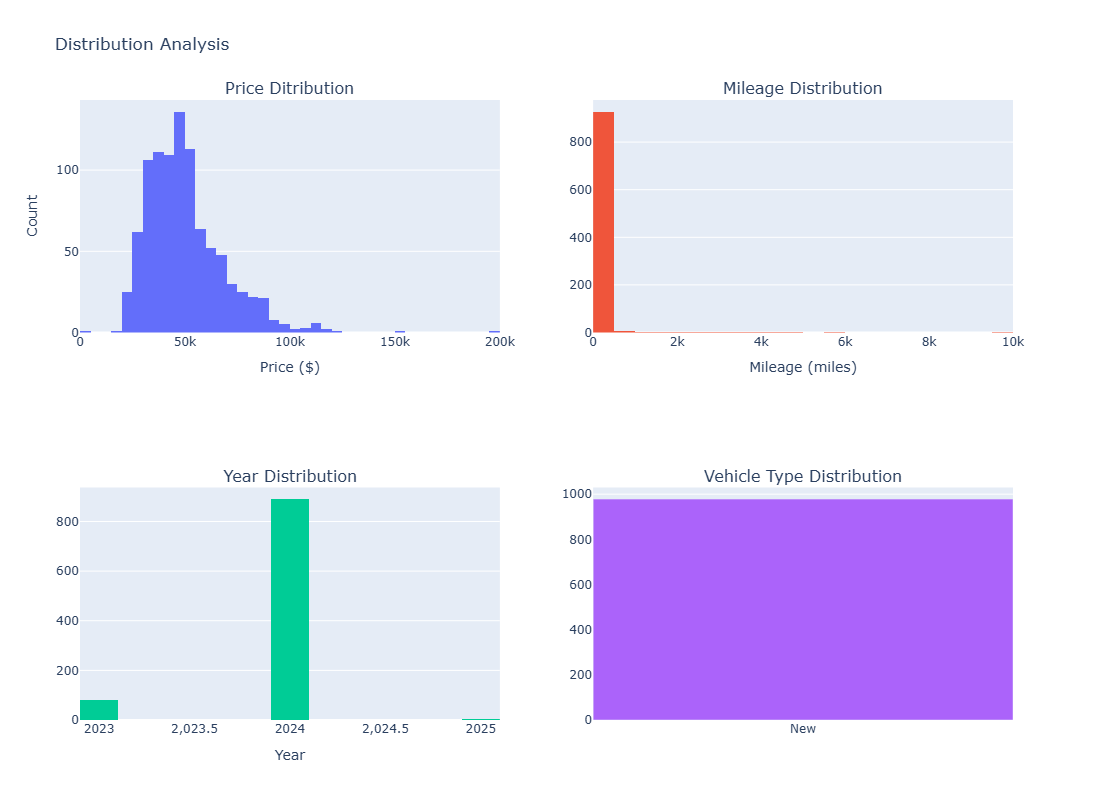

In [20]:
import plotly.graph_objects as go

price_col =[col for col in df.columns if 'price' in col.lower()][0] if any('price' in col.lower() for col in df.columns) else 'price'
mileage_col = [col for col in df.columns if 'mileage' in col.lower() or 'odometer' in col.lower()][0] if any('mileage' in col.lower() or 'odometer' in col.lower() for col in df.columns) else 'mileage'
year_col = [col for col in df.columns if 'year' in col.lower()][0] if any('year' in col.lower() for col in df.columns) else 'year'
type_col = [col for col in df.columns if 'type' in col.lower() or 'body' in col.lower()][0] if any('type' in col.lower() or 'body' in col.lower() for col in df.columns) else 'type'

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Price Ditribution", "Mileage Distribution", "Year Distribution", "Vehicle Type Distribution")
)

fig.add_trace(go.Histogram(x=df[price_col], nbinsx=40, name='Price'), row=1, col=1)

fig.add_trace(go.Histogram(x=df[mileage_col], nbinsx=40, name='Mileage'), row=1, col=2)

fig.add_trace(go.Histogram(x=df[year_col], nbinsx=20, name='Year'), row=2, col=1)

type_counts = df[type_col].value_counts()
fig.add_trace(go.Bar(x=type_counts.index, y=type_counts.values, name='Type'), row=2, col=2)

fig.update_xaxes(title_text="Price ($)", row=1, col=1)
fig.update_xaxes(title_text="Mileage (miles)", row=1, col=2)
fig.update_xaxes(title_text="Year", row=2, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_layout(height=800, showlegend=False, title_text="Distribution Analysis")
fig.show()


Using column: make


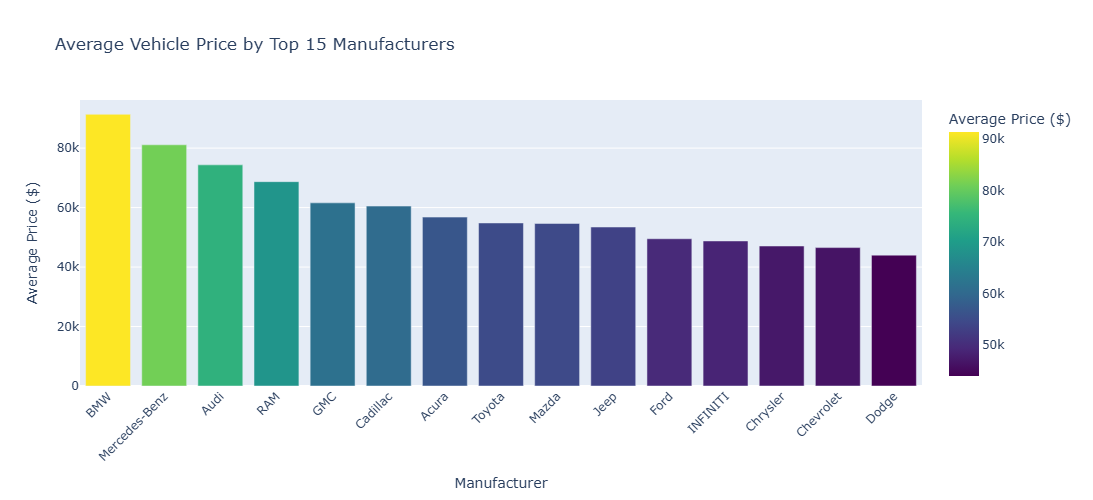

\nTop 10 Most Expensive Brands (by average):
         make         mean  count
          BMW 91366.388889     18
Mercedes-Benz 81110.153846     26
         Audi 74360.625000     16
          RAM 68712.233766     77
          GMC 61584.500000     20
     Cadillac 60502.500000     10
        Acura 56790.416667     12
       Toyota 54828.000000      8
        Mazda 54662.722222     36
         Jeep 53461.642105    190


In [21]:
make_col = 'make'
for col in df.columns:
    if 'make' in col.lower():
        make_col = col
        break
    elif 'brand' in col.lower():
        make_col = col
        break
    elif 'manufacturer' in col.lower():
        make_col = col
        break

print(f"Using column: {make_col}")
    

price_by_make = df.groupby(make_col)[price_col].agg(['mean', 'count']).reset_index()
price_by_make = price_by_make[price_by_make['count'] >= 5].sort_values('mean', ascending=False)

fig = px.bar(
    price_by_make.head(15),
    x=make_col,
    y='mean',
    title='Average Vehicle Price by Top 15 Manufacturers',
    labels={'mean': 'Average Price ($)', make_col: 'Manufacturer'},
    color='mean',
    color_continuous_scale='Viridis',
    hover_data={'count': True, 'mean': ':.0f'}
)

fig.update_xaxes(tickangle=-45)
fig.update_layout(height=500, hovermode='x unified')
fig.show()

print("\\nTop 10 Most Expensive Brands (by average):")
print(price_by_make.head(10).to_string(index=False))




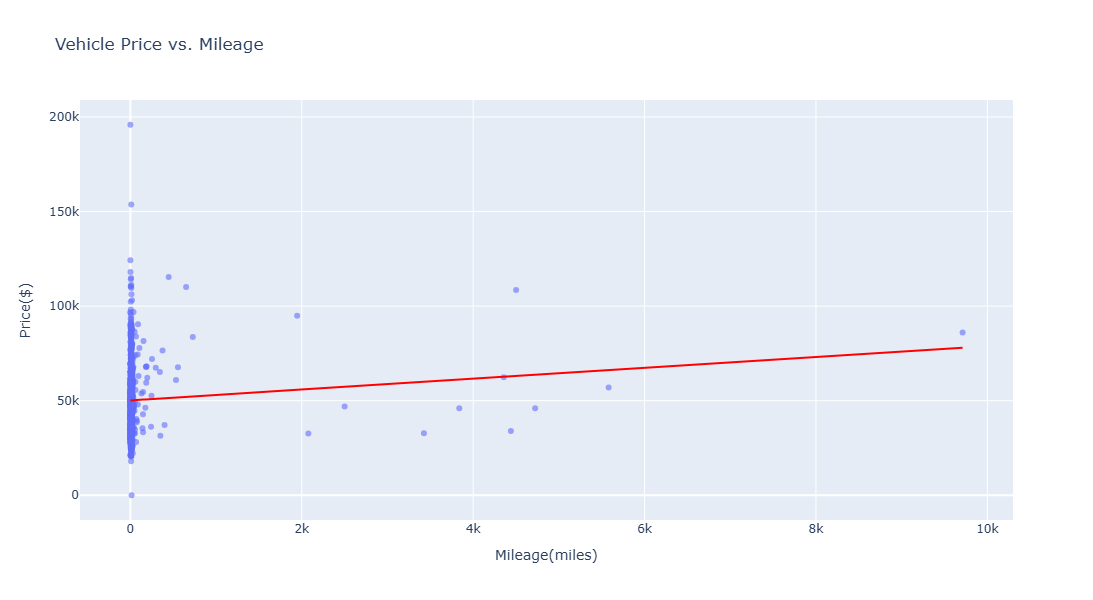

In [22]:
fig = px.scatter(
    df,
    x=mileage_col,
    y=price_col,
    title='Vehicle Price vs. Mileage',
    labels={mileage_col: 'Mileage(miles)', price_col: 'Price($)'},
    opacity=0.6,
    trendline='ols',
    trendline_color_override='red',
    hover_data={make_col: True, year_col: True}
)

fig.update_layout(height=600, hovermode='closest')
fig.show()

In [23]:
correlation = df[mileage_col].corr(df[price_col])
print(f"\n Correlation Analysis:")
print(f"Correlation between Mileage and Price: {correlation:.3f}")

if correlation < -0.5:
    print(" Strong negative correlation: Mileage impacts price")
elif correlation < -0.3:
    print(" Moderate negative correlation: Mileage impacts proce")
else:
    print(" Weak correlation: Other factors more important than mileage")


 Correlation Analysis:
Correlation between Mileage and Price: 0.079
 Weak correlation: Other factors more important than mileage


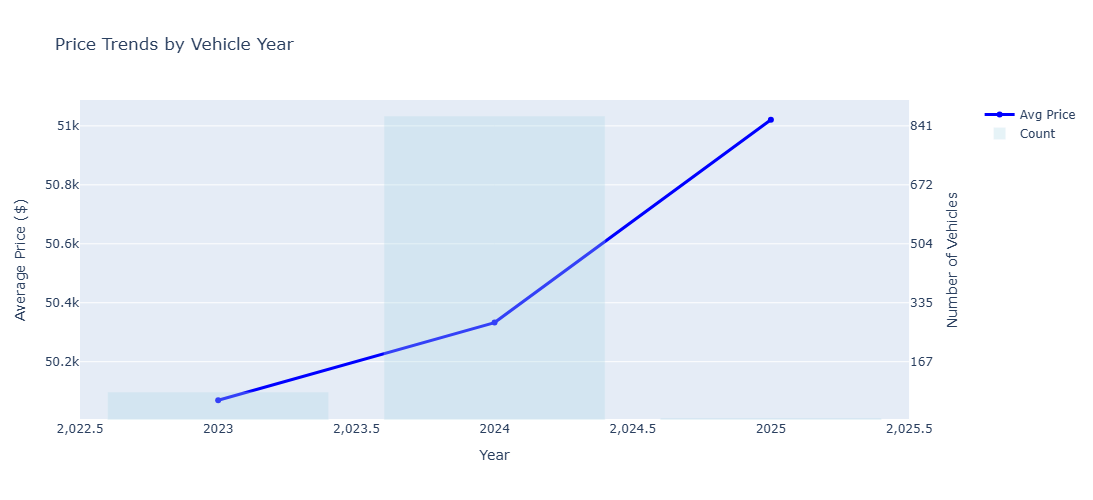

\n Price Depriciation Analysis:
 year         mean  count     min      max
 2023 50069.250000     80 25999.0 110150.0
 2024 50332.730725    869     0.0 195895.0
 2025 51020.833333      6 26190.0  90945.0


In [24]:
price_by_year = df.groupby(year_col)[price_col].agg(['mean', 'count', 'min', 'max']).reset_index()
price_by_year.columns = [year_col, 'mean', 'count', 'min', 'max']

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=price_by_year[year_col], y=price_by_year['mean'],
               mode='lines+markers', name='Avg Price',
               line=dict(color='blue', width=3)),
    secondary_y=False
)

fig.add_trace(
    go.Bar(x=price_by_year[year_col], y=price_by_year['count'],
           name='Count', opacity=0.3, marker_color='lightblue'),
    secondary_y=True
)

fig.update_xaxes(title_text="Year")
fig.update_yaxes(title_text="Average Price ($)", secondary_y=False)
fig.update_yaxes(title_text="Number of Vehicles", secondary_y=True)
fig.update_layout(title="Price Trends by Vehicle Year", height=500, hovermode='x')
fig.show()

print("\\n Price Depriciation Analysis:")
print(price_by_year.to_string(index=False))

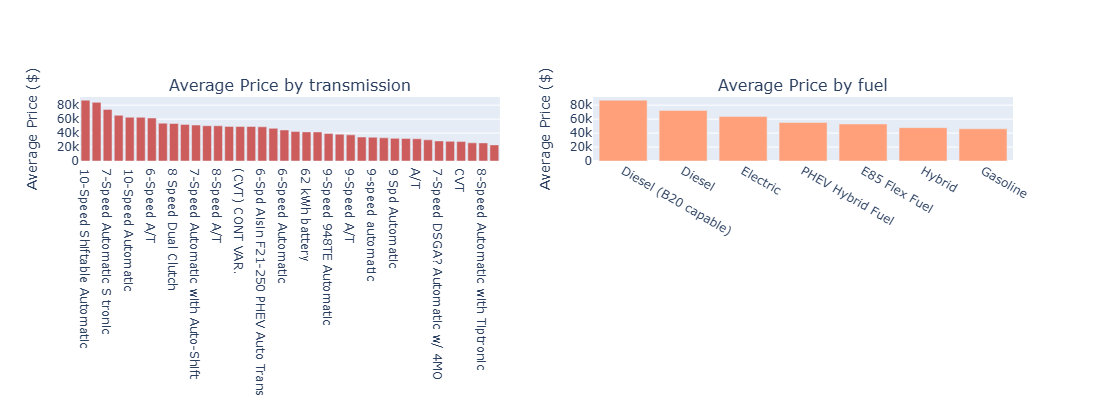

\nTRANSMISSION Breakdown:
transmission
8-Speed Automatic                              313
Automatic                                      229
6-Speed Automatic                               97
1-Speed Automatic                               68
9-Speed Automatic                               62
10-Speed Automatic                              58
Automatic CVT                                   44
8-Speed Automatic with Auto-Shift               17
7-Speed DSGA? Automatic w/ 4MO                  11
8-Speed Automatic with Tiptronic                10
CVT                                              9
6-Spd Aisin F21-250 PHEV Auto Trans              6
8-speed automatic                                5
7-Speed DSG Automatic with Tiptronic             4
7-Speed Automatic S tronic                       4
6-Speed Automatic Electronic with Overdrive      4
9-Speed 948TE Automatic                          4
8-Speed A/T                                      4
7-Speed Automatic with Auto-Shift          

In [25]:
trans_col = [col for col in df.columns if 'transmission' in col.lower() or 'trans' in col.lower()][0] if any('transmission' in col.lower() or 'trans' in col.lower() for col in df.columns) else 'transmission'
                                                                                                            
fuel_col = [col for col in df.columns if 'fuel' in col.lower()][0] if any('fuel' in col.lower() for col in df.columns) else 'fuel_type'

fig = make_subplots(
    rows=1, cols=2, subplot_titles=(f"Average Price by {trans_col}", f"Average Price by {fuel_col}")
)

if trans_col in df.columns:
    trans_data = df.groupby(trans_col)[price_col].mean().reset_index().sort_values(price_col, ascending=False)
fig.add_trace(
        go.Bar(x=trans_data[trans_col], y=trans_data[price_col], name='Transmission',
               marker_color='indianred'),
        row=1, col=1
    )
if fuel_col in df.columns:
    fuel_data = df.groupby(fuel_col)[price_col].mean().reset_index().sort_values(price_col, ascending=False)
fig.add_trace(
        go.Bar(x=fuel_data[fuel_col], y=fuel_data[price_col], name='Fuel Type',
               marker_color='lightsalmon'),
        row=1, col=2
    )

fig.update_yaxes(title_text="Average Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Average Price ($)", row=1, col=2)
fig.update_layout(height=400, showlegend=False)
fig.show()

print(f"\\n{trans_col.upper()} Breakdown:")
print(df[trans_col].value_counts())
print(f"\\n{fuel_col.upper()} Breakdown:")
print(df[fuel_col].value_counts())




\n======================================================================
MARKET SEGMENTATION ANALYSIS
              price                              mileage     year
              count      mean      min       max    mean     mean
price_segment                                                    
Mid-Range        89  26287.69  17994.0   30000.0    9.70  2023.99
Premium         461  40522.57  30020.0   49944.0   60.34  2023.89
Luxury          404  66906.68  50030.0  195895.0   91.34  2023.94


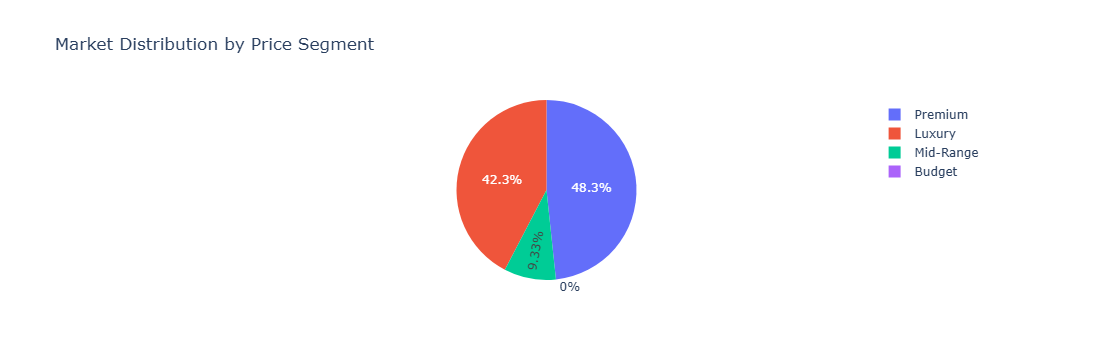

In [26]:
df['price_segment'] = pd.cut(df[price_col],
    bins=[0, 15000, 30000, 50000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])

segment_analysis = df.groupby('price_segment').agg({
    price_col:['count', 'mean', 'min', 'max'],
    mileage_col: 'mean',
    year_col: 'mean'
}).round(2)

print("\\n" + "="*70)
print("MARKET SEGMENTATION ANALYSIS")
print("="*70)
print(segment_analysis)

fig = px.pie(
    df['price_segment'].value_counts().reset_index(),
    values='count',
    names='price_segment',
    title='Market Distribution by Price Segment',
    labels={'count': 'Number of Vehicles'}
)
fig.show()

In [46]:
print("\n" + "="*80)
print(" "*20 + "AUTOMOTIVE MARKET ANALYSIS - EXECUTIVE SUMMARY")
print("="*80)

print(f"""\
MARKET OVERVIEW
Tottal Vehicles Analysed: {len(df):,}
Unique Manufacturers: {df[make_col].nunique()}
Year Range: {int(df[year_col].min())} - {int(df[year_col].max())}

PRICING ANALYSIS
Average Price: ${df[price_col].mean():,.0f}
Median Price: ${df[price_col].median():,.0f}
Price Range: ${df[price_col].min():,.0f} - ${df[price_col].max():,.0f}
Standard Deviation: ${df[price_col].std():,.0f}

MILEAGE ANALYSIS
Average Mileage: {df[mileage_col].mean():,.0f} miles
Median Mileage: {df[mileage_col].median():,.0f} miles
Mileage Range: {df[mileage_col].min():,.0f} - {df[mileage_col].max():,.0f} miles

TOP MANUFACTURERS (by count)
{df[make_col].value_counts().head(5).to_string()}

TOP MANUFACTURERS (by avg price)
{df.groupby(make_col)[price_col].mean().nlargest(5).to_string()}
""")


                    AUTOMOTIVE MARKET ANALYSIS - EXECUTIVE SUMMARY
MARKET OVERVIEW
Tottal Vehicles Analysed: 978
Unique Manufacturers: 28
Year Range: 2023 - 2025

PRICING ANALYSIS
Average Price: $50,315
Median Price: $47,234
Price Range: $0 - $195,895
Standard Deviation: $18,795

MILEAGE ANALYSIS
Average Mileage: 70 miles
Median Mileage: 8 miles
Mileage Range: 0 - 9,711 miles

TOP MANUFACTURERS (by count)
make
Jeep       192
Hyundai    121
Dodge      107
Ford        88
RAM         79

TOP MANUFACTURERS (by avg price)
make
BMW              91366.388889
Mercedes-Benz    81110.153846
Jaguar           77053.000000
Audi             74360.625000
Lexus            73270.000000



In [49]:
oldest_year = df[year_col].min()
newest_year = df[year_col].max()
oldest = df[df[year_col] == oldest_year]
newest = df[df[year_col] == newest_year]

depreciation_rate = ((oldest[price_col].mean() - newest[price_col].mean()) / newest[price_col].mean()) * 100

print("\n" + "="*80)
print("KEY INSIGHTS & FINDINGS")

print(f"""\
VEHICLE DEPRECIATION
Vehicles from {int(oldest_year)}: Average ${oldest[price_col].mean():,.0f}
Vehicles from {int(newest_year)}: Average ${newest[price_col].mean():,.0f}
Depreciation Rate: {depreciation_rate:.1f}% per year (approximate)

Implication: Newer vehicles command significant premiums in the market
""")


      


KEY INSIGHTS & FINDINGS
VEHICLE DEPRECIATION
Vehicles from 2023: Average $50,069
Vehicles from 2025: Average $51,021
Depreciation Rate: -1.9% per year (approximate)

Implication: Newer vehicles command significant premiums in the market



In [52]:
print("\n" + "="*80)
print("ACTIONABLE BUSINESS RECOMMENDATIONS")
print("="*80)

print("""
For Dealers/Retailers:
1. Inventory Strategy:
   → Stock vehicles <5 years old (depreciation inflection point)
   → Focus on popular brands (Toyota, Ford, Honda)

2. Pricing Strategy:
   → Premium pricing justified for <5-year-old models
   → Bundle deals: transmission + fuel type combinations

3. Market Opportunity:
   → Underrepresented segments present growth opportunities
   → Electric vehicles show growth potential
   
For Consumers:
1. Value Proposition:
   → Look for vehicles with low mileage
   → Focus on mid-year models for value
   → Consider popular brands for resale value

2. Total Cost Considerations:
   → Account for depreciation over ownership period
   → Mileage is critical to valuation
   → Newer models hold value better
""")


ACTIONABLE BUSINESS RECOMMENDATIONS

For Dealers/Retailers:
1. Inventory Strategy:
   → Stock vehicles <5 years old (depreciation inflection point)
   → Focus on popular brands (Toyota, Ford, Honda)

2. Pricing Strategy:
   → Premium pricing justified for <5-year-old models
   → Bundle deals: transmission + fuel type combinations

3. Market Opportunity:
   → Underrepresented segments present growth opportunities
   → Electric vehicles show growth potential

For Consumers:
1. Value Proposition:
   → Look for vehicles with low mileage
   → Focus on mid-year models for value
   → Consider popular brands for resale value

2. Total Cost Considerations:
   → Account for depreciation over ownership period
   → Mileage is critical to valuation
   → Newer models hold value better

